Training RNN...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


687/687 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5428 - loss: 0.9271 - val_accuracy: 0.6474 - val_loss: 0.7927
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.8035 - loss: 0.5066 - val_accuracy: 0.6429 - val_loss: 0.9249
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - accuracy: 0.9190 - loss: 0.2259 - val_accuracy: 0.6203 - val_loss: 1.1965
Training LSTM...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6388 - loss: 0.8027 - val_accuracy: 0.7166 - val_loss: 0.6805
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 141s 132ms/step - accuracy: 0.7989 - loss: 0.5094 - val_accuracy: 0.7093 - val_loss: 0.7056
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 92s 134ms/step - accuracy: 0.8726 - loss: 0.3438 - val_accuracy: 0.6967 - val_loss: 0.8475
Training GRU...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.6386 - loss: 0.8029 - val_accuracy: 0.7162 - val_loss: 0.6758
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 80s 116ms/step - accura

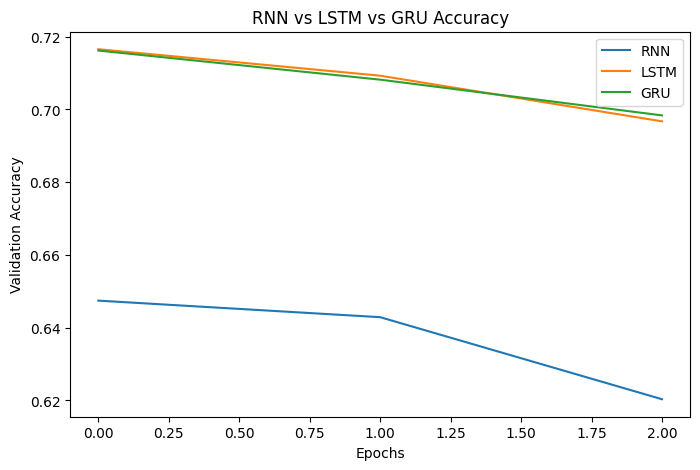


----- LAST EPOCH VAL ACCURACY -----
RNN Val Accuracy: 0.6203
LSTM Val Accuracy: 0.6967
GRU Val Accuracy: 0.6984


In [ ]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -------------------- LOAD DATA --------------------
df = pd.read_csv("Tweets.csv")

df['label'] = df['sentiment'].map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})

texts = df['text'].astype(str).values
labels = df['label'].values

# -------------------- TOKENIZATION --------------------
tokenizer = Tokenizer(num_words=80000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=50)

# -------------------- SPLIT --------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

# -------------------- MODELS --------------------
def build_rnn():
    model = Sequential([
        Embedding(80000, 128, input_length=50),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_lstm():
    model = Sequential([
        Embedding(80000, 128, input_length=50),
        LSTM(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_gru():
    model = Sequential([
        Embedding(80000, 128, input_length=50),
        GRU(128),
        Dense(3, activation='softmax')
    ])
    return model

models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}

# -------------------- TRAIN --------------------
histories = {}

for name, model in models.items():
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )

    print(f"Training {name}...")

    history = model.fit(
        x_train, y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    histories[name] = history

# -------------------- PLOT --------------------
plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("RNN vs LSTM vs GRU Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

print("\n----- LAST EPOCH VAL ACCURACY -----")

for name, history in histories.items():
    acc = history.history['val_accuracy'][-1]
    print(f"{name} Val Accuracy: {acc:.4f}")
